# $F_D$ on a slab-normal plane vs a vertical plane

At the trench the plate has begun to bend, so a vertical plane is no longer truly plate-perpendicular. The standard differential-stress resultant

$$F_D \;=\; \int_0^{z_\max}(\tau_{xx} - \tau_{zz})\,dz$$

evaluated on a vertical plane through the trench therefore mixes plate-parallel and plate-perpendicular stress components. Here we recompute $F_D$ on a **truly slab-normal plane** and compare.

**Steps.** (1) estimate the local dip $\theta$ from the angle of an isotherm in the lithosphere interior near the trench; (2) build a slab-normal integration path from the trench surface point in direction $(-\sin\theta, \cos\theta)$; (3) sample $\tau_{xx}, \tau_{zz}, \tau_{xz}$ along that path; (4) rotate the deviatoric stress into slab coordinates $(\xi, \eta)$ where $\xi$ is slab-parallel and $\eta$ is slab-perpendicular:

$$\tau_{\xi\xi} - \tau_{\eta\eta} \;=\; (\tau_{xx} - \tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$$

(5) integrate along $\eta$.

Setup duplicates `cerpa_single_step.ipynb` (config, helpers, grid) so `MODEL_KEY` and `TIMESTEP_INDEX` work the same way.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same as `cerpa_single_step.ipynb`. Change `MODEL_KEY` / `TIMESTEP_INDEX` to swap.

In [2]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'
TIMESTEP_INDEX = 10

DX        = 500.0
Z_MAX     = 100_000.0
Y_SURFACE = 2_900_000.0

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Model {MODEL_KEY!r} timestep {i}: {ff.split('/')[-1]}")

# === Mirror flag ============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: tloc + SEAWARD_SIGN * offset_metres
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


Model 'WAL' timestep 10: subduction_with_LM_10.pvtu
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

`get_field` reshapes a sampled VTK array onto the regular grid. The 3-step trench picker (and its sub-helpers) is duplicated from `cerpa_single_step.ipynb`.

In [3]:
import sys
from pathlib import Path
# cerpa_helpers lives in notebooks/, one level above further_analysis/
_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)

from cerpa_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    load_records,
)


## 4. Load PVTU and build the regular grid

Sample the unstructured Fluidity output onto a uniform `DX`-spaced grid; extract $T$, $p$, $\tau_{xx}, \tau_{zz}, \tau_{xz}$, and $v_x$ as 2-D arrays indexed `[z, x]`.

In [4]:
vtk_data = pv.read(ff)
t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

# === Coordinate convention =================================================
# Model frame: (x, y) with y vertical UP.  Notebook frame: (x, z) with
# z = Y_SURFACE - y, depth positive DOWN.  The reflection y -> -z flips
# off-diagonal stress components: sigma_xz_zdown = -sigma_xy_yup.  We apply
# that flip HERE at extraction so all downstream code is in z-down convention.
vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]   # sigma_xz_zdown = -sigma_xy_yup
vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
vtk_data.point_data['vx']  = vel[:, 0]
vtk_data.point_data['vy']  = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX
X, Z = np.meshgrid(x, z, indexing='xy')
Y = Y_SURFACE - Z
grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

p   = get_field('p')
txx = get_field('txx')
tzz = get_field('tzz')
txz = get_field('txz')
T   = get_field('T')
fs  = get_field('fs')
vx  = get_field('vx')
vz  = -get_field('vy')

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print('(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)')

print(f'grid: {p.shape}  x in [{x[0]/1e3:.0f}, {x[-1]/1e3:.0f}] km, z in [{z[0]/1e3:.1f}, {z[-1]/1e3:.1f}] km')


(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
grid: (200, 15999)  x in [0, 7999] km, z in [0.2, 99.8] km


## 5. Trench identification

In [5]:
tloc, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000, Wv_km=800, Wp3_km=800,
    smooth_km=40, subducting_side=SUBDUCTING_SIDE,
)
tindx = int(np.argmin(np.abs(x - tloc)))
print(f'Trench at x = {tloc/1e3:.1f} km (index {tindx})')


Trench at x = 4440.2 km (index 8880)


## 6. Slab dip from interior isotherm

Pick an isotherm well inside the lithosphere (`T_ISO ~ 600-800°C`). For each $x$ in a symmetric window of half-width `WINDOW_KM` around the trench, find the depth where $T(x, z) = T_\mathrm{iso}$ and fit a line to those points. The slope gives $\tan\theta$.

In [6]:
T_ISO     = 800.0   # °C — middle of lithosphere
WINDOW_KM = 10      # half-width of symmetric window (± WINDOW_KM around trench)

x_lo = tloc - WINDOW_KM * 1000.0
x_hi = tloc + WINDOW_KM * 1000.0
ix_window = np.where((x >= x_lo) & (x <= x_hi))[0]

z_iso = []
for ix in ix_window:
    Tcol = T[:, ix]
    if not np.all(np.isfinite(Tcol)) or T_ISO <= Tcol[0] or T_ISO >= Tcol[-1]:
        z_iso.append(np.nan)
        continue
    z_iso.append(np.interp(T_ISO, Tcol, z))
z_iso = np.array(z_iso)
x_window = x[ix_window]

good = np.isfinite(z_iso)
m, b = np.polyfit(x_window[good], z_iso[good], 1)
dip = float(np.arctan(m))   # in radians
print(f'Slab dip from {T_ISO:.0f}°C isotherm (over ±{WINDOW_KM} km around trench): {np.rad2deg(dip):.2f}°')
print(f'  isotherm depth at trench  ≈ {b + m*tloc:7.0f} m  ({(b + m*tloc)/1e3:.1f} km)')

Slab dip from 800°C isotherm (over ±10 km around trench): -3.21°
  isotherm depth at trench  ≈   28524 m  (28.5 km)


## 7. Build slab-normal integration path and sample stresses

Slab-normal direction (into the rock from the surface): $\hat{\eta} = (-\sin\theta, \cos\theta)$. Path starts at the trench surface point and steps along $\hat{\eta}$ for length $L$.

In [7]:
L_PATH = Z_MAX             # length along slab-normal path (m); same as vertical extent
DS     = 100.0             # step size along path (m)

n_steps = int(L_PATH / DS) + 1
s_path = np.arange(n_steps) * DS

nx_hat = -np.sin(dip)      # slab-normal direction
nz_hat = +np.cos(dip)

x_path = tloc + s_path * nx_hat
z_path = z[0] + s_path * nz_hat   # start at first row of grid (z = 500 m), not z = 0

# Interpolate stresses along the path
def make_interp(field):
    return RegularGridInterpolator((z, x), field, bounds_error=False, fill_value=np.nan)

fT   = make_interp(T)
ftxx = make_interp(txx)
ftzz = make_interp(tzz)
ftxz = make_interp(txz)

pts = np.column_stack([z_path, x_path])
T_path   = fT(pts)
txx_path = ftxx(pts)
tzz_path = ftzz(pts)
txz_path = ftxz(pts)

# Rotated differential stress: τ_ξξ - τ_ηη
two_theta = 2 * dip
diff_rotated  = (txx_path - tzz_path) * np.cos(two_theta) + 2 * txz_path * np.sin(two_theta)
diff_vertical = txx[:, tindx] - tzz[:, tindx]   # along the vertical column

## 8. $F_D$ — vertical vs slab-normal


F_D on vertical   plane:   -0.598  TN/m
F_D on slab-normal plane:  -0.390  TN/m
difference:  +0.208  TN/m
(slab-normal − vertical) / vertical = -34.7 %


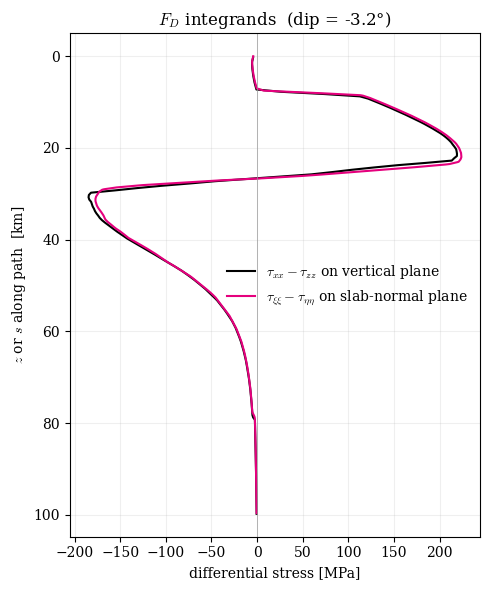

In [8]:
F_D_vertical    = np.trapz(diff_vertical, z)
F_D_slab_normal = np.trapz(diff_rotated[np.isfinite(diff_rotated)],
                            s_path[np.isfinite(diff_rotated)])

print(f'F_D on vertical   plane:  {F_D_vertical    * 1e-12:+7.3f}  TN/m')
print(f'F_D on slab-normal plane: {F_D_slab_normal * 1e-12:+7.3f}  TN/m')
print(f'difference: {(F_D_slab_normal - F_D_vertical)*1e-12:+7.3f}  TN/m')
print(f'(slab-normal − vertical) / vertical = {(F_D_slab_normal/F_D_vertical - 1)*100:+.1f} %' if F_D_vertical != 0 else '')

# Plot the integrand on each path so you can see WHERE F_D comes from
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(diff_vertical*1e-6, z*1e-3, 'k-', lw=1.5, label=r'$\tau_{xx}-\tau_{zz}$ on vertical plane')
ax.plot(diff_rotated *1e-6, s_path*1e-3, color='#E5007D', lw=1.5,
        label=r'$\tau_{\xi\xi}-\tau_{\eta\eta}$ on slab-normal plane')
ax.axvline(0, color='0.6', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('differential stress [MPa]')
ax.set_ylabel(r'$z$ or $s$ along path  [km]')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.set_title(f'$F_D$ integrands  (dip = {np.rad2deg(dip):.1f}°)')
fig.tight_layout()
plt.show()

## 9. Visualisation — verify the path orientation

Zoomed view of the trench region with: temperature field as background, the chosen isotherm (gold), the linear dip fit (dashed), the vertical line and the slab-normal path. Use this to confirm the slab-normal path actually follows the lithosphere.

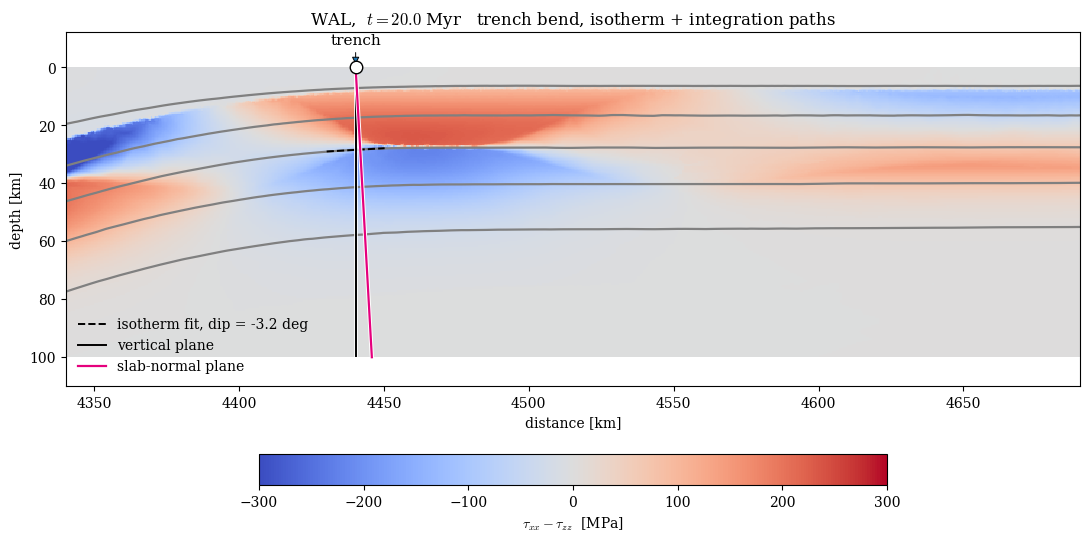

In [9]:
# After x-mirror the trailing plate is on the right and the slab descends
# leftward, so the asymmetric zoom shows mostly +x relative to the trench.
WIN_X_KM = 250
WIN_Z_KM = 110
x_lo_v = tloc - 100e3
x_hi_v = tloc + WIN_X_KM * 1e3
ix_v   = (x >= x_lo_v) & (x <= x_hi_v)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(x[ix_v]*1e-3, z*1e-3,                                                                                                                                                             
                     (txx[:, ix_v] - tzz[:, ix_v]) * 1e-6,    # Pa -> MPa
                     cmap='coolwarm', shading='auto', vmin=-300, vmax=300)            

cbar = fig.colorbar(im, ax=ax,                            
                      label=r'$\tau_{xx} - \tau_{zz}$  [MPa]',                                                                                                                                         
                      orientation='horizontal', fraction=0.06, pad=0.13)

ax.contour(x[ix_v]*1e-3, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='grey', linewidths=1.6)

x_fit = np.linspace(x_window.min(), x_window.max(), 60)
ax.plot(x_fit*1e-3, (m*x_fit + b)*1e-3, 'k--', lw=1.4,
        label=f'isotherm fit, dip = {np.rad2deg(dip):.1f} deg')

ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='white', lw=2.6)
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='black', lw=1.4, label='vertical plane')

ax.plot(x_path*1e-3, z_path*1e-3, color='white', lw=3.0)
ax.plot(x_path*1e-3, z_path*1e-3, color='#E5007D', lw=1.6, label='slab-normal plane')

ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=5)
ax.annotate('trench', xy=(tloc*1e-3, 0), xytext=(tloc*1e-3, -8),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='-|>', lw=0.7))

ax.invert_yaxis()
ax.set_xlim(x_lo_v*1e-3, x_hi_v*1e-3)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance [km]')
ax.set_ylabel('depth [km]')
ax.set_aspect('equal')
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr   trench bend, isotherm + integration paths')
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_path_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 10. Time loop — $F_D$ across all snapshots

Repeat the §4–§8 recipe at every snapshot.  Capture three arrays:

- `Fd_vert_arr` — $F_D$ on a vertical plane through the trench
- `Fd_slabn_arr` — $F_D$ on the slab-normal plane (rotated deviatoric stress, integrated along the slab-normal path)
- `Fd_slabn_h_arr` — horizontal projection of the slab-normal resultant, $F_D^{slab-normal}\cos\theta$


In [10]:
import gc
from scipy.interpolate import RegularGridInterpolator

t_yr_arr       = []
Fd_vert_arr    = []
Fd_slabn_arr   = []
Fd_slabn_h_arr = []        # horizontal projection: F_D_slab_normal * cos(dip)
dip_arr        = []

for i_step, ff_step in enumerate(pvtu_files):
    if i_step == 0:
        continue
    try:
        # --- read pvtu --------------------------------------------------
        vd = pv.read(ff_step)
        t_yr_s = float(np.asarray(vd['NormalSP::Time']).flat[0]) / 31_557_600.0
        vd.point_data['p']   = vd['NormalSP::Pressure']
        vd.point_data['txx'] = vd['NormalSP::Stress'][:, 0]
        vd.point_data['tzz'] = vd['NormalSP::Stress'][:, 4]
        vd.point_data['txz'] = -vd['NormalSP::Stress'][:, 1]
        vd.point_data['T']   = vd['NormalSP::Temperature']
        vd.point_data['vx']  = (vd['NormalSP::Velocity'] / 3.17098e-10)[:, 0]

        # --- grid + interpolate ----------------------------------------
        x_min_s, x_max_s, _, _, _, _ = vd.bounds
        nx_s = int((x_max_s - x_min_s) / DX); nz_s = int(Z_MAX / DX)
        x_s = x_min_s + (np.arange(nx_s) + 0.5) * DX
        z_s = (np.arange(nz_s) + 0.5) * DX
        Xs, Zs = np.meshgrid(x_s, z_s, indexing='xy')
        Ys = Y_SURFACE - Zs
        gs = pv.StructuredGrid(Xs.T, Ys.T, np.zeros_like(Xs.T))
        ip = gs.sample(vd)
        nxp, nzp, _ = ip.dimensions
        vmask = ip['vtkValidPointMask'].reshape((nxp, nzp), order='F').astype(bool)
        gf = make_field_extractor(ip, nxp, nzp, vmask)

        p_s   = gf('p');   txx_s = gf('txx'); tzz_s = gf('tzz')
        txz_s = gf('txz'); T_s   = gf('T');   vx_s  = gf('vx')
        if MIRROR_X:
            zero = np.zeros_like(p_s)
            p_s, txx_s, tzz_s, txz_s, T_s, _, vx_s, _ = mirror_fields_in_x(
                p_s, txx_s, tzz_s, txz_s, T_s, zero, vx_s, zero)

        # --- trench -----------------------------------------------------
        tloc_s, _ = pick_trench_3step(
            x_s, z_s, p_s, vx_s,
            vx_depth_m=5000, Wv_km=800, Wp3_km=800,
            smooth_km=40, subducting_side=SUBDUCTING_SIDE,
        )
        tindx_s = int(np.argmin(np.abs(x_s - tloc_s)))

        # --- dip from isotherm window ----------------------------------
        x_lo_s = tloc_s - WINDOW_KM * 1000.0
        x_hi_s = tloc_s + WINDOW_KM * 1000.0
        ixw = np.where((x_s >= x_lo_s) & (x_s <= x_hi_s))[0]
        zi = []
        for ix in ixw:
            Tc = T_s[:, ix]
            if not np.all(np.isfinite(Tc)) or T_ISO <= Tc[0] or T_ISO >= Tc[-1]:
                zi.append(np.nan); continue
            zi.append(np.interp(T_ISO, Tc, z_s))
        zi = np.array(zi)
        good = np.isfinite(zi)
        if good.sum() < 3:
            raise RuntimeError('isotherm fit has too few points')
        ms, bs = np.polyfit(x_s[ixw][good], zi[good], 1)
        dip_s = float(np.arctan(ms))

        # --- slab-normal path + integrand ------------------------------
        nxh = -np.sin(dip_s); nzh = +np.cos(dip_s)
        x_path_s = tloc_s + s_path * nxh
        z_path_s = z_s[0] + s_path * nzh
        ft_xx = RegularGridInterpolator((z_s, x_s), txx_s, bounds_error=False, fill_value=np.nan)
        ft_zz = RegularGridInterpolator((z_s, x_s), tzz_s, bounds_error=False, fill_value=np.nan)
        ft_xz = RegularGridInterpolator((z_s, x_s), txz_s, bounds_error=False, fill_value=np.nan)
        pts = np.column_stack([z_path_s, x_path_s])
        txx_p = ft_xx(pts); tzz_p = ft_zz(pts); txz_p = ft_xz(pts)
        two_th = 2 * dip_s
        diff_rot  = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)
        diff_vert = txx_s[:, tindx_s] - tzz_s[:, tindx_s]

        F_vert  = np.trapz(diff_vert, z_s)
        fin = np.isfinite(diff_rot)
        F_slabn = np.trapz(diff_rot[fin], s_path[fin])
        F_slabn_h = F_slabn * np.cos(dip_s)

        t_yr_arr.append(t_yr_s)
        Fd_vert_arr.append(F_vert)
        Fd_slabn_arr.append(F_slabn)
        Fd_slabn_h_arr.append(F_slabn_h)
        dip_arr.append(dip_s)

        if i_step % 5 == 0:
            print(f'  [{i_step:>3}] t = {t_yr_s/1e6:5.2f} Myr  '
                  f'dip = {np.rad2deg(dip_s):5.1f}°   '
                  f'F_vert = {F_vert*1e-12:+6.2f}   '
                  f'F_slabn = {F_slabn*1e-12:+6.2f}   '
                  f'F_slabn_h = {F_slabn_h*1e-12:+6.2f}  TN/m')

        del vd, gs, ip
        gc.collect()
    except Exception as e:
        print(f'  [{i_step}] failed: {e}; skipping')
        continue

t_yr_arr       = np.array(t_yr_arr)
Fd_vert_arr    = np.array(Fd_vert_arr)
Fd_slabn_arr   = np.array(Fd_slabn_arr)
Fd_slabn_h_arr = np.array(Fd_slabn_h_arr)
dip_arr        = np.array(dip_arr)

print(f'\ncaptured {len(t_yr_arr)} snapshots')


  [  5] t = 10.01 Myr  dip =  -3.4°   F_vert =  -0.84   F_slabn =  -0.69   F_slabn_h =  -0.69  TN/m
  [ 10] t = 20.01 Myr  dip =  -3.2°   F_vert =  -0.60   F_slabn =  -0.39   F_slabn_h =  -0.39  TN/m
  [ 15] t = 30.00 Myr  dip =  -3.6°   F_vert =  -1.85   F_slabn =  -1.58   F_slabn_h =  -1.58  TN/m
  [ 20] t = 40.00 Myr  dip =  -3.1°   F_vert =  -1.89   F_slabn =  -1.72   F_slabn_h =  -1.72  TN/m
  [ 25] t = 49.98 Myr  dip =  -2.9°   F_vert =  -2.00   F_slabn =  -1.86   F_slabn_h =  -1.86  TN/m
  [ 30] t = 59.96 Myr  dip =  -2.7°   F_vert =  -3.29   F_slabn =  -3.13   F_slabn_h =  -3.13  TN/m
  [ 35] t = 69.97 Myr  dip =  -3.4°   F_vert =  -4.12   F_slabn =  -3.68   F_slabn_h =  -3.67  TN/m
  [ 40] t = 79.95 Myr  dip =  -3.7°   F_vert =  -4.05   F_slabn =  -3.73   F_slabn_h =  -3.72  TN/m

captured 40 snapshots


## 11. Plot — $F_D$ vs time on the three planes


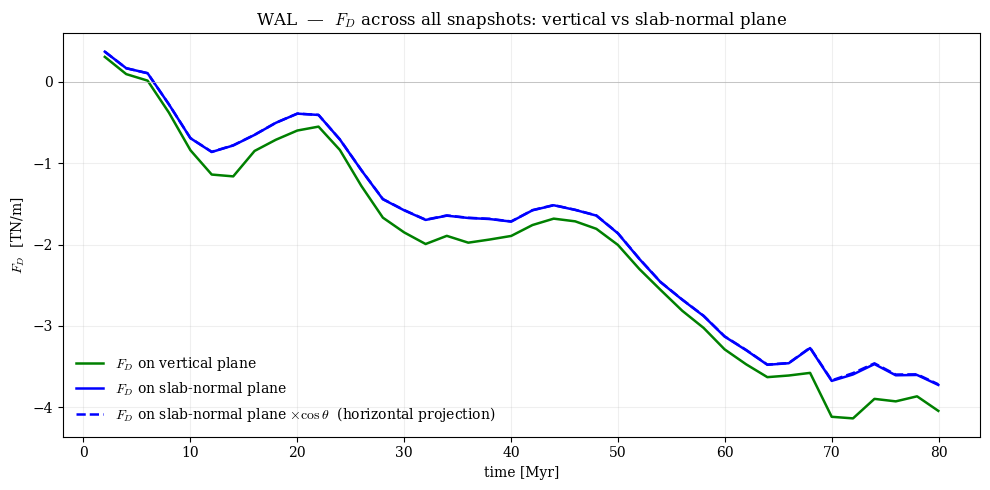

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_yr_arr/1e6, Fd_vert_arr    * 1e-12, color='green',     ls='-',  lw=1.8,
        label=r'$F_D$ on vertical plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_arr   * 1e-12, color='blue',  ls='-',  lw=1.8,
        label=r'$F_D$ on slab-normal plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_h_arr * 1e-12, color='blue',  ls='--', lw=1.8,
        label=r'$F_D$ on slab-normal plane $\times\cos\theta$  (horizontal projection)')
ax.axhline(0, color='0.7', lw=0.5)
ax.set_xlabel('time [Myr]')
ax.set_ylabel(r'$F_D$  [TN/m]')
ax.set_title(f'{MODEL_KEY}  —  $F_D$ across all snapshots: vertical vs slab-normal plane')
ax.legend(loc='best', frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_FD_evolution_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()
